<a href="https://colab.research.google.com/github/ShubhGuPTA-cmd/ML-experiments/blob/main/exp_3pynb_%5Bbayesian%2Cridge%2Crobust%2Clinear%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LinearRegression,
    BayesianRidge,
    HuberRegressor,
    Ridge
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['IMG-20240322-WA0003.jpg', '_EWA7113.jpg', '_E3A9368.jpg', '_MG_7670.jpg', 'Classroom', 'Saved from the Google app', 'eCurricula', 'Leetcode Assignment 717.docx', 'Colab Notebooks', 'e3abb9c0-6139-49a0-b085-44a3b7f8d7ed.jpeg']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['IMG-20240322-WA0003.jpg', '_EWA7113.jpg', '_E3A9368.jpg', '_MG_7670.jpg', 'Classroom', 'Saved from the Google app', 'eCurricula', 'Leetcode Assignment 717.docx', 'Colab Notebooks', 'e3abb9c0-6139-49a0-b085-44a3b7f8d7ed.jpeg', 'insurance.csv.zip']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))


['IMG-20240322-WA0003.jpg', '_EWA7113.jpg', '_E3A9368.jpg', '_MG_7670.jpg', 'Classroom', 'Saved from the Google app', 'eCurricula', 'Leetcode Assignment 717.docx', 'Colab Notebooks', 'e3abb9c0-6139-49a0-b085-44a3b7f8d7ed.jpeg', 'insurance.csv.zip', 'ML_Lab']


In [ ]:
print(os.listdir('/content/drive/MyDrive/ML_Lab'))

['insurance.csv.zip']


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ML_Lab/insurance.csv.zip'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LinearRegression,
    BayesianRidge,
    HuberRegressor,
    Ridge
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [ ]:
X = df[['bmi']]
y = df['charges']

print("Feature:", X.columns.tolist())
print("Target:", y.name)

Feature: ['bmi']
Target: charges


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1070
Testing samples: 268


In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("LINEAR REGRESSION")
print("-----------------")
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)
print("R²  :", linear_r2)

LINEAR REGRESSION
-----------------
MSE : 149085057.03839505
RMSE: 12210.039190698571
MAE : 9784.65259627133
R²  : 0.03970193117941878


In [ ]:
bayesian_model = BayesianRidge()

bayesian_model.fit(X_train, y_train)

bayesian_pred = bayesian_model.predict(X_test)

bayesian_mse = mean_squared_error(y_test, bayesian_pred)
bayesian_rmse = np.sqrt(bayesian_mse)
bayesian_mae = mean_absolute_error(y_test, bayesian_pred)
bayesian_r2 = r2_score(y_test, bayesian_pred)

print("BAYESIAN LINEAR REGRESSION")
print("--------------------------")
print("MSE :", bayesian_mse)
print("RMSE:", bayesian_rmse)
print("MAE :", bayesian_mae)
print("R²  :", bayesian_r2)

BAYESIAN LINEAR REGRESSION
--------------------------
MSE : 149092081.24775302
RMSE: 12210.326828048175
MAE : 9776.713812632284
R²  : 0.03965668630501307


In [ ]:
robust_model = HuberRegressor()

robust_model.fit(X_train, y_train)

robust_pred = robust_model.predict(X_test)

robust_mse = mean_squared_error(y_test, robust_pred)
robust_rmse = np.sqrt(robust_mse)
robust_mae = mean_absolute_error(y_test, robust_pred)
robust_r2 = r2_score(y_test, robust_pred)

print("ROBUST REGRESSION")
print("-----------------")
print("MSE :", robust_mse)
print("RMSE:", robust_rmse)
print("MAE :", robust_mae)
print("R²  :", robust_r2)

ROBUST REGRESSION
-----------------
MSE : 160248631.97663975
RMSE: 12658.93486738279
MAE : 8698.630377314976
R²  : -0.032205741308303226


In [ ]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("RIDGE REGRESSION")
print("----------------")
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("MAE :", ridge_mae)
print("R²  :", ridge_r2)

RIDGE REGRESSION
----------------
MSE : 149085061.19973135
RMSE: 12210.039361104917
MAE : 9784.643711752811
R²  : 0.03970190437510113


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Bayesian Linear Regression',
        'Robust Regression',
        'Ridge Regression'
    ],

    'MSE': [
        linear_mse,
        bayesian_mse,
        robust_mse,
        ridge_mse
    ],

    'RMSE': [
        linear_rmse,
        bayesian_rmse,
        robust_rmse,
        ridge_rmse
    ],

    'MAE': [
        linear_mae,
        bayesian_mae,
        robust_mae,
        ridge_mae
    ],

    'R²': [
        linear_r2,
        bayesian_r2,
        robust_r2,
        ridge_r2
    ]
})

comparison.round(4)

,Model,MSE,RMSE,MAE,R²
0,Linear Regression,1.490851e+08,12210.0392,9784.6526,0.0397
1,Bayesian Linear Regression,1.490921e+08,12210.3268,9776.7138,0.0397
2,Robust Regression,1.602486e+08,12658.9349,8698.6304,-0.0322
3,Ridge Regression,1.490851e+08,12210.0394,9784.6437,0.0397


In [ ]:
best_rmse_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

print("Best Model based on RMSE:")
print(best_rmse_model)

Best Model based on RMSE:
Model    Linear Regression
MSE       149085057.038395
RMSE          12210.039191
MAE            9784.652596
R²                0.039702
Name: 0, dtype: object


In [ ]:
best_mae_model = comparison.loc[
    comparison['MAE'].idxmin()
]

print("Best Model based on MAE:")
print(best_mae_model)

Best Model based on MAE:
Model    Robust Regression
MSE        160248631.97664
RMSE          12658.934867
MAE            8698.630377
R²               -0.032206
Name: 2, dtype: object


In [ ]:
best_r2_model = comparison.loc[
    comparison['R²'].idxmax()
]

print("Best Model based on R²:")
print(best_r2_model)

Best Model based on R²:
Model    Linear Regression
MSE       149085057.038395
RMSE          12210.039191
MAE            9784.652596
R²                0.039702
Name: 0, dtype: object


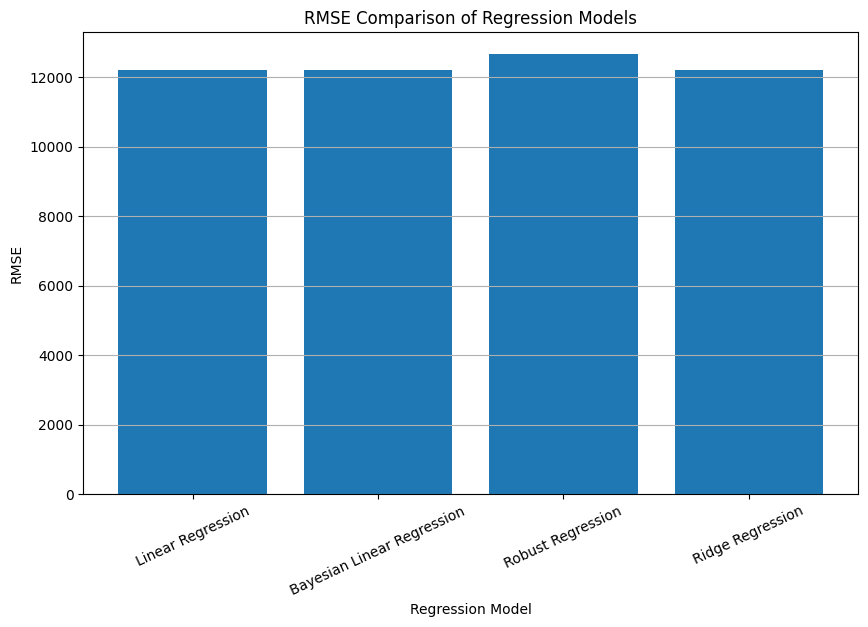

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.xlabel('Regression Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Regression Models')

plt.xticks(rotation=25)
plt.grid(axis='y')

plt.show()

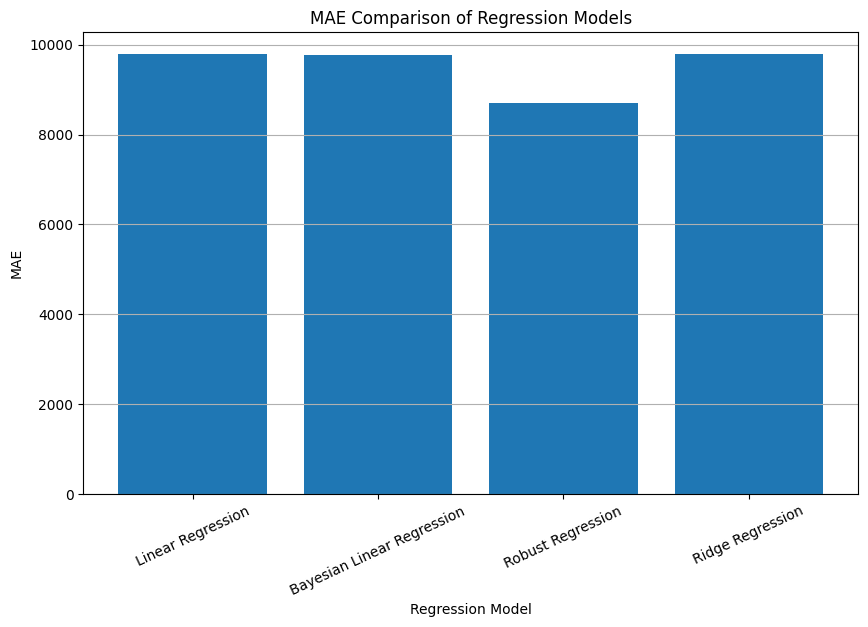

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.xlabel('Regression Model')
plt.ylabel('MAE')
plt.title('MAE Comparison of Regression Models')

plt.xticks(rotation=25)
plt.grid(axis='y')

plt.show()

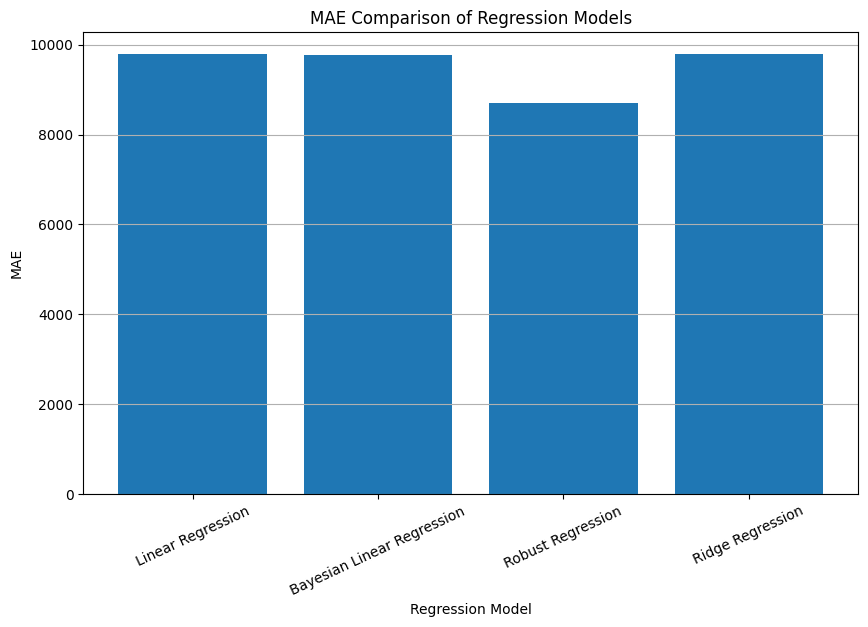

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.xlabel('Regression Model')
plt.ylabel('MAE')
plt.title('MAE Comparison of Regression Models')

plt.xticks(rotation=25)
plt.grid(axis='y')

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BayesianRidge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HuberRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


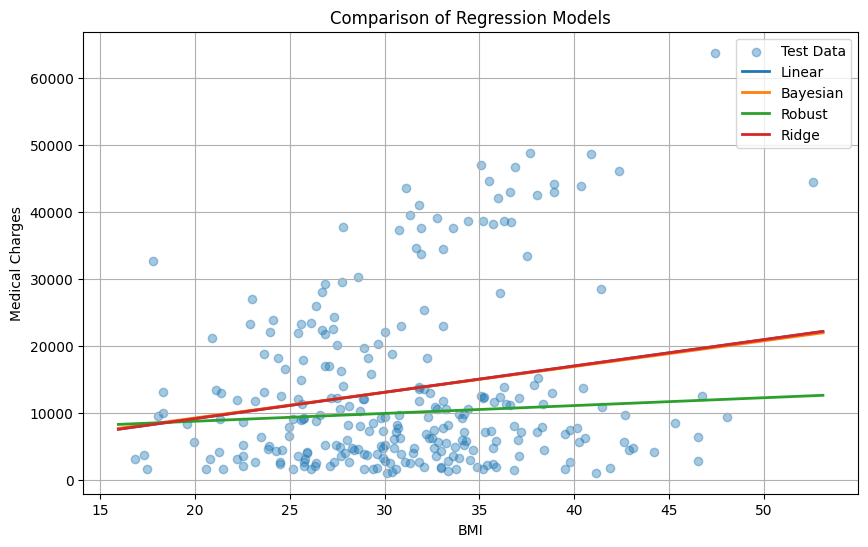

In [ ]:
X_plot = np.linspace(
    X['bmi'].min(),
    X['bmi'].max(),
    500
).reshape(-1, 1)

linear_line = linear_model.predict(X_plot)
bayesian_line = bayesian_model.predict(X_plot)
robust_line = robust_model.predict(X_plot)
ridge_line = ridge_model.predict(X_plot)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.4,
    label='Test Data'
)

plt.plot(
    X_plot,
    linear_line,
    linewidth=2,
    label='Linear'
)

plt.plot(
    X_plot,
    bayesian_line,
    linewidth=2,
    label='Bayesian'
)

plt.plot(
    X_plot,
    robust_line,
    linewidth=2,
    label='Robust'
)

plt.plot(
    X_plot,
    ridge_line,
    linewidth=2,
    label='Ridge'
)

plt.xlabel('BMI')
plt.ylabel('Medical Charges')

plt.title('Comparison of Regression Models')

plt.legend()
plt.grid(True)

plt.show()